# Import Library & Set Globals

In [1]:
# base
import os
import sys
import gc
import warnings
import logging
import pickle

# data manipulation
import pickle
import pandas as pd
import itables
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

# single cell
import anndata as ad
import scanpy as sc
import decoupler as dc
import gseapy as gp

itables.init_notebook_mode(connected=True)  # Use connected=False for offline use
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

from rpy2.robjects.conversion import localconverter

converter = get_converter()

# R_preload()
%load_ext rpy2.ipython

CORES = 10
DATADIR = Path("../../../data") / "processed" / "single_cell"
REFDIR = Path("../../../references")
DOUBLETMETHODS = ["scDblFinder", "DoubletFinder", "doubletdetection", "scrublet"]
study = "Emont2022"
data_folder = DATADIR / "cellranger" / "Emont_download"

%matplotlib inline
mpl.rcdefaults()
gc.collect()

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


2026-01-27 10:12:35 | [INFO] cffi mode is CFFI_MODE.ANY
2026-01-27 10:12:35 | [INFO] R home found: /opt/R/4.4.1/lib/R
2026-01-27 10:12:35 | [INFO] R library path: /opt/R/4.4.1/lib/R/lib:/usr/local/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/java-11-openjdk-amd64/lib/server
2026-01-27 10:12:35 | [INFO] LD_LIBRARY_PATH: /opt/R/4.4.1/lib/R/lib:/usr/local/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/java-11-openjdk-amd64/lib/server
2026-01-27 10:12:35 | [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2026-01-27 10:12:35 | [INFO] Environment variable "PWD" redefined by R and overriding existing variable. Current: "/mnt/DATA/home/ethung", R: "/mnt/DATA/home/ethung/spatial_seq/src/notebooks/single_cell"
2026-01-27 10:12:35 | [INFO] R is already initialized. No need to initialize.
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` nam

404

# Access adata

In [58]:
adata = sc.read_10x_mtx(DATADIR / "raw" / "Emont2022")
annotations = pd.read_csv(
    data_folder / "GSE176171_cell_metadata.tsv.gz", sep="\t", index_col=0
)
annotations = annotations[annotations["species__ontology_label"] == "Mus musculus"]
adata.obs = annotations.loc[adata.obs_names.tolist()]
adata.layers["counts"] = adata.X.copy()

In [59]:
# save
adata.obs.rename(columns={"biosample_id": "Identifier"}, inplace=True)
nan_cols = adata.obs.columns[adata.obs.dtypes == "object"]
adata.obs[nan_cols] = adata.obs[nan_cols].astype(str)

savedir = DATADIR / "processed" / "single cell" / study
os.makedirs(savedir, exist_ok=True)
adata.write_zarr(savedir / "cleaned")
gc.collect()

... storing 'Identifier' as categorical
... storing 'biosample_type' as categorical
... storing 'library_preparation_protocol__ontology_id' as categorical
... storing 'library_preparation_protocol__ontology_label' as categorical
... storing 'donor_id' as categorical
... storing 'species__ontology_id' as categorical
... storing 'species__ontology_label' as categorical
... storing 'organ__ontology_id' as categorical
... storing 'organ__ontology_label' as categorical
... storing 'tissue__ontology_id' as categorical
... storing 'tissue__ontology_label' as categorical
... storing 'tissue__type__ontology_id' as categorical
... storing 'tissue__type__ontology_label' as categorical
... storing 'depot__ontology_id' as categorical
... storing 'depot__ontology_label' as categorical
... storing 'fat__type' as categorical
... storing 'sex__ontology_id' as categorical
... storing 'sex__ontology_label' as categorical
... storing 'race__ontology_id' as categorical
... storing 'race__ontology_label' as

4026

In [7]:
# load
adata = ad.read_zarr(DATADIR / study / "cleaned")
print(adata)
gc.collect()

AnnData object with n_obs × n_vars = 197721 × 25180
    obs: 'Identifier', 'biosample_type', 'library_preparation_protocol__ontology_id', 'library_preparation_protocol__ontology_label', 'donor_id', 'species__ontology_id', 'species__ontology_label', 'organ__ontology_id', 'organ__ontology_label', 'tissue__ontology_id', 'tissue__ontology_label', 'tissue__type__ontology_id', 'tissue__type__ontology_label', 'depot__ontology_id', 'depot__ontology_label', 'fat__type', 'sex__ontology_id', 'sex__ontology_label', 'race__ontology_id', 'race__ontology_label', 'ethnicity__ontology_id', 'ethnicity__ontology_label', 'mouse_strain__ontology_id', 'mouse_strain__ontology_label', 'development_stage__ontology_id', 'development_stage__ontology_label', 'organism_age', 'organism_age__unit__ontology_id', 'organism_age__unit__ontology_label', 'organism_age__group', 'organism_weight', 'organism_weight__unit__ontology_id', 'organism_weight__unit__ontology_label', 'disease__ontology_id', 'disease__ontology_label'

0

begin preprocessing at Mon Jan 26 15:28:23 2026, (total: 0:00:00.000023)
Saving normalized counts in layer 'normalized'.
Finding HVGs...
Staring PCA with gene mask highly_variable at 50 comps, saved at .obsm[PCA_hvg]


2026-01-26 15:29:56,928 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-01-26 15:29:56 | [INFO] Running Harmony (PyTorch on cpu)
2026-01-26 15:29:56,930 - harmonypy - INFO -   Parameters:
2026-01-26 15:29:56 | [INFO]   Parameters:
2026-01-26 15:29:56,931 - harmonypy - INFO -     max_iter_harmony: 10
2026-01-26 15:29:56 | [INFO]     max_iter_harmony: 10
2026-01-26 15:29:56,931 - harmonypy - INFO -     max_iter_kmeans: 20
2026-01-26 15:29:56 | [INFO]     max_iter_kmeans: 20
2026-01-26 15:29:56,932 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-01-26 15:29:56 | [INFO]     epsilon_cluster: 1e-05
2026-01-26 15:29:56,933 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-01-26 15:29:56 | [INFO]     epsilon_harmony: 0.0001
2026-01-26 15:29:56,934 - harmonypy - INFO -     nclust: 100
2026-01-26 15:29:56 | [INFO]     nclust: 100
2026-01-26 15:29:56,935 - harmonypy - INFO -     block_size: 0.05
2026-01-26 15:29:56 | [INFO]     block_size: 0.05
2026-01-26 15:29:56,936 - harmon

Integrating by Column Identifier: ['Mm_ING_16-1', 'Mm_POV_01-1', 'Mm_ING_17-1', 'Mm_POV_02-1', 'Mm_POV_03-1', ..., 'Mm_ING_24-1', 'Mm_EPI_19-1', 'Mm_ING_10-1', 'Mm_ING_10-2', 'Mm_ING_11-1']
Length: 26
Categories (26, object): ['Mm_EPI_10-1', 'Mm_EPI_10-2', 'Mm_EPI_11-1', 'Mm_EPI_12-1', ..., 'Mm_POV_01-1', 'Mm_POV_02-1', 'Mm_POV_03-1', 'Mm_POV_04-1']


2026-01-26 15:30:03,343 - harmonypy - INFO - KMeans initialization complete.
2026-01-26 15:30:03 | [INFO] KMeans initialization complete.
2026-01-26 15:30:03,631 - harmonypy - INFO - Iteration 1 of 10
2026-01-26 15:30:03 | [INFO] Iteration 1 of 10
2026-01-26 15:30:15,746 - harmonypy - INFO - Iteration 2 of 10
2026-01-26 15:30:15 | [INFO] Iteration 2 of 10
2026-01-26 15:30:27,581 - harmonypy - INFO - Iteration 3 of 10
2026-01-26 15:30:27 | [INFO] Iteration 3 of 10
2026-01-26 15:30:39,682 - harmonypy - INFO - Iteration 4 of 10
2026-01-26 15:30:39 | [INFO] Iteration 4 of 10
2026-01-26 15:30:47,911 - harmonypy - INFO - Iteration 5 of 10
2026-01-26 15:30:47 | [INFO] Iteration 5 of 10
2026-01-26 15:30:55,689 - harmonypy - INFO - Converged after 5 iterations
2026-01-26 15:30:55 | [INFO] Converged after 5 iterations


Starting UMAP...


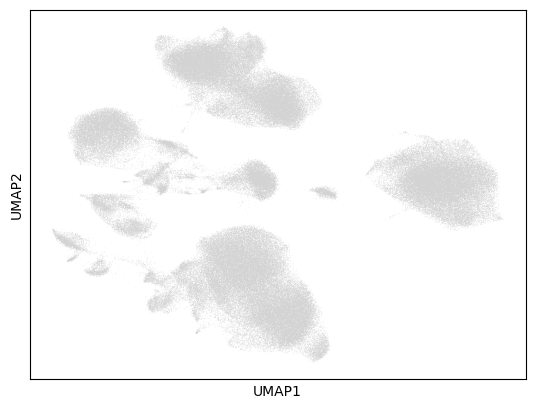

Starting LocalMAP...


KeyboardInterrupt: 

In [8]:
start = stopwatch("preprocessing", time())
Normalize(adata)
FindVariableGenes(adata, batch_column="Identifier")
PCA(adata)
Integrate(adata, batch_column="Identifier")
Visualize(adata)
gc.collect()
stopwatch(start=start, setting=1)

<Axes: title={'center': 'cell_type__ontology_label'}, xlabel='UMAP1', ylabel='UMAP2'>

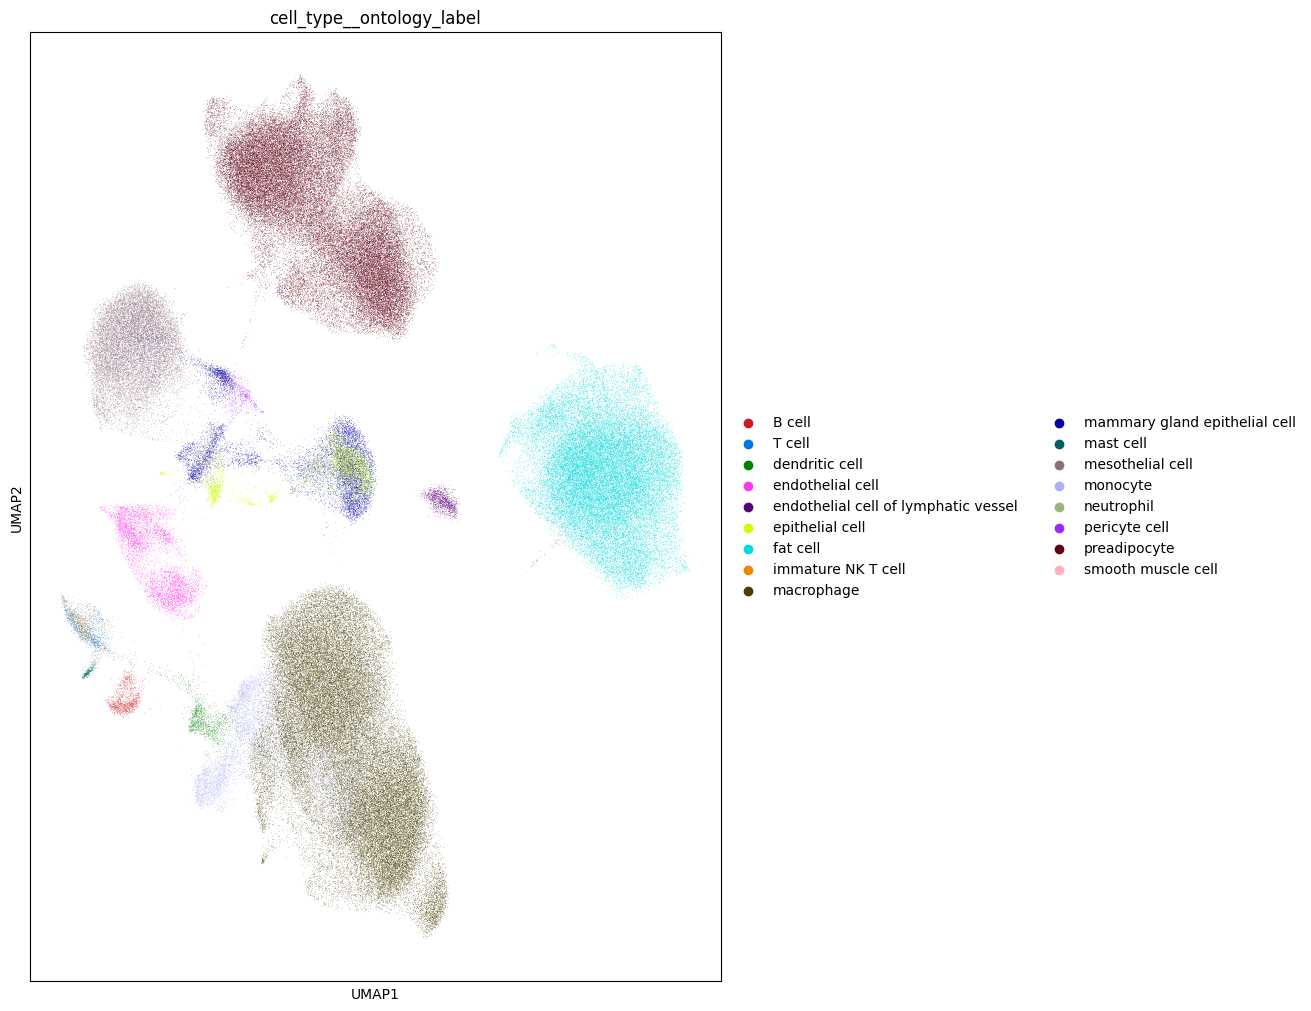

In [12]:
f, ax = plt.subplots(1, 1, layout="constrained", figsize=(13, 10))
sc.pl.embedding(
    adata,
    "UMAP",
    color="cell_type__ontology_label",
    ax=ax,
    show=False,
    palette=color_gen(adata.obs["cell_type__ontology_label"]),
)

# f, ax = plt.subplots(1, 1, layout="constrained", figsize=(13, 10))
# sc.pl.embedding(adata, "LocalMAP", color="cell_type__custom", ax=ax, show=False)

In [ ]:
savedir = DATADIR / "processed" / "single cell" / study
adata.write_zarr(savedir / "cleaned")
print(adata)
gc.collect()

AnnData object with n_obs × n_vars = 194030 × 25177
    obs: 'Identifier', 'biosample_type', 'library_preparation_protocol__ontology_id', 'library_preparation_protocol__ontology_label', 'donor_id', 'species__ontology_id', 'species__ontology_label', 'organ__ontology_id', 'organ__ontology_label', 'tissue__ontology_id', 'tissue__ontology_label', 'tissue__type__ontology_id', 'tissue__type__ontology_label', 'depot__ontology_id', 'depot__ontology_label', 'fat__type', 'sex__ontology_id', 'sex__ontology_label', 'race__ontology_id', 'race__ontology_label', 'ethnicity__ontology_id', 'ethnicity__ontology_label', 'mouse_strain__ontology_id', 'mouse_strain__ontology_label', 'development_stage__ontology_id', 'development_stage__ontology_label', 'organism_age', 'organism_age__unit__ontology_id', 'organism_age__unit__ontology_label', 'organism_age__group', 'organism_weight', 'organism_weight__unit__ontology_id', 'organism_weight__unit__ontology_label', 'disease__ontology_id', 'disease__ontology_label'

6163

# Fibroblast Exploration

In [27]:
SELECT_RES = [0.4]
CELLTYPE_ADDON = "fibro"
DE_KEY = f"DEG_{CELLTYPE_ADDON}"
CLUSTER_KEY = f"leiden_{CELLTYPE_ADDON}"
resolutions = np.arange(1, 11) / 10

### Preprocess

In [ ]:
fb_adata = adata[adata.obs["cell_type__custom"] == "ASPC"]

begin preprocessing at Mon Jan 26 16:20:55 2026, (total: 0:00:00.000010)
Cells removed by gene/count filters: 0 (0.00%)
Starting UMAP...


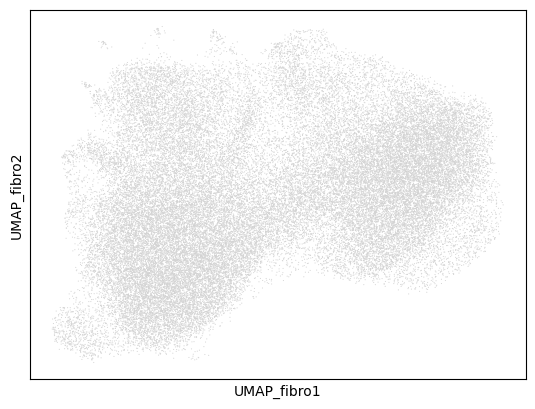

Starting LocalMAP...


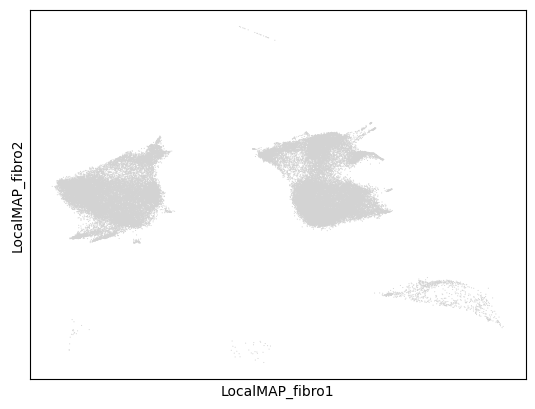

finished in 0:02:44.351618



2375

In [ ]:
start = stopwatch("preprocessing", time())
Filter_QC(fb_adata)
Visualize(fb_adata, key=CELLTYPE_ADDON)
stopwatch(start=start, setting=1)
gc.collect()

In [ ]:
Cluster(fb_adata, "leiden_fibro", resolutions)
for key in [col for col in fb_adata.obs.columns if "leiden_fibro" in col]:
    sc.pl.embedding(
        fb_adata,
        "UMAP_fibro",
        color=key,
        palette=color_gen(fb_adata.obs[key]),
        legend_loc="on data",
    )

In [60]:
fb_adata = fb_adata[
    ~fb_adata.obs["leiden_fibro_0.1"].isin(pd.Series(np.arange(3, 42)).astype(str))
]

Category fat__type has 2 groups!


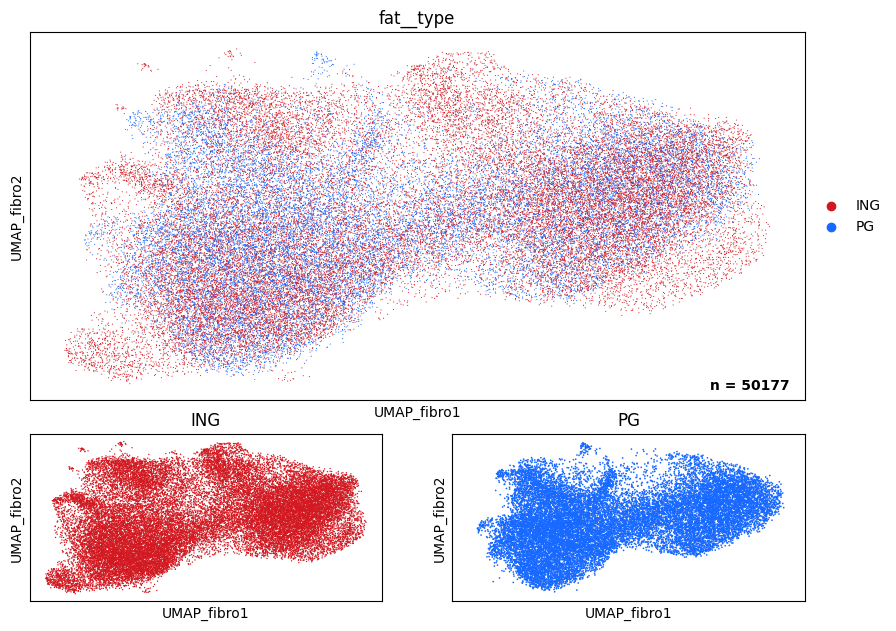

In [ ]:
check_integration(fb_adata, "fat__type", f, ["UMAP_fibro"], nrow=2, ncol=2)

In [56]:
ewat_fb_adata = fb_adata[fb_adata.obs["fat__type"] == "PG"].copy()
res_key = "leiden_fibro_0.4"
clear_adata(ewat_fb_adata, "colors")

['colors']
deleted from `obs`:  Index([], dtype='object')
deleted from `var`:  Index([], dtype='object')
deleted from `uns`:  cell_type__custom_colors
deleted from `uns`:  cell_type__ontology_label_colors
deleted from `uns`:  fat__type_colors
deleted from `uns`:  leiden_fibro_0.1_colors
deleted from `uns`:  leiden_fibro_0.2_colors
deleted from `uns`:  leiden_fibro_0.3_colors
deleted from `uns`:  leiden_fibro_0.4_colors
deleted from `uns`:  leiden_fibro_0.5_colors
deleted from `uns`:  leiden_fibro_0.6_colors
deleted from `uns`:  leiden_fibro_0.7_colors
deleted from `uns`:  leiden_fibro_0.8_colors
deleted from `uns`:  leiden_fibro_0.9_colors
deleted from `uns`:  leiden_fibro_1.0_colors




### Initial Look

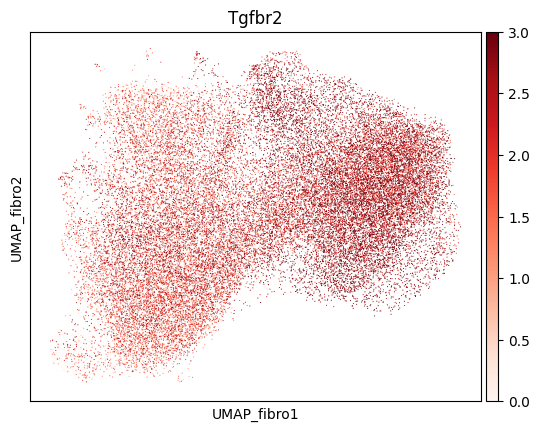

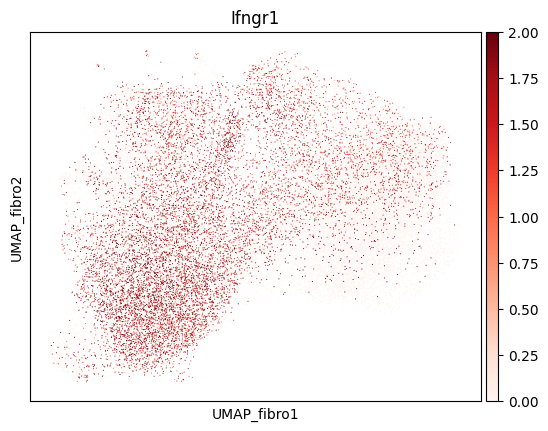

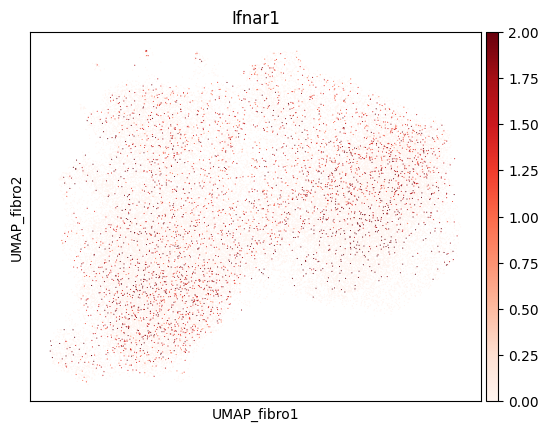

In [148]:
sc.pl.embedding(
    fb_adata, "UMAP_fibro", color="Tgfbr2", layer="normalized", cmap="Reds", vmax=3
)
sc.pl.embedding(
    fb_adata, "UMAP_fibro", color="Ifngr1", layer="normalized", cmap="Reds", vmax=2
)
sc.pl.embedding(
    fb_adata, "UMAP_fibro", color="Ifnar1", layer="normalized", cmap="Reds", vmax=2
)

In [62]:
from gseapy import Msigdb

cytokine_responses = {
    "TGFb-resp low": ["Smad2", "Smad3", "Smad4", "Serpine1", "Id1", "Id2", "Id3"],
    "TGFb-resp high": ["Fn1", "Postn", "Cthrc1", "Vim", "Col1a1", "Col1a2", "Serpinh1"],
    "IFN genes": [
        "Fasn",
        "Irs1",
        "Insr",
        "Irf3",
        "Irf4",
        "Ifi47",
        "Irf1",
        "Ifitm1",
        "Ifitm2",
        "Ifitm3",
        "Isg15",
        "Cxcl9",
        "Cxcl10",
    ],
    "General IFN/TGFb": [
        "Ifngr1",
        "Ifnar1",
        "Tgfbr2",
        "Il33",
        "Il31ra",
        "Il17ra",
        "Il17rb",
    ],
}

# print(Msigdb.list_dbver())
# print(Msigdb.list_category())
hallmark = Msigdb.get_gmt(category="mh.all", dbver="2025.1.Mm")
hallmark_geneset = {
    "TGFb_HM": hallmark["HALLMARK_TGF_BETA_SIGNALING"],
    "IFNa_HM": hallmark["HALLMARK_INTERFERON_ALPHA_RESPONSE"],
    "IFNg_HM": hallmark["HALLMARK_INTERFERON_GAMMA_RESPONSE"],
}

custom_geneset = {
    "Cytokine-responsive_geneset": [
        "Col1a1",
        "Col1a2",
        "Serpinh1",
        "Postn",
        "Tgfbr2",
        "Fn1",
        "Ifngr1",
        "Ifitm3",
    ]
}

In [63]:
# module scores
clear_adata(ewat_fb_adata, ["UCell", "Seurat"])
for method in ["UCell", "Seurat"]:
    module_score(
        ewat_fb_adata,
        custom_geneset | hallmark_geneset,
        method,
        True if method == "Seurat" else False,
    )

['UCell', 'Seurat']
deleted from `obs`:  Index([], dtype='object')
deleted from `var`:  Index([], dtype='object')


deleted from `obs`:  Index([], dtype='object')
deleted from `var`:  Index([], dtype='object')




/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resour

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scanpy/tools/_score_genes.py:241: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scanpy/tools/_score_genes.py:241: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scanpy/tools/_score_genes.py:241: Deprecation

       'Rigi', 'Slamf7', 'Tmt1b', 'Upp1', 'Wars1', 'Xcl1'],
      dtype='object')


/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scanpy/tools/_score_genes.py:241: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scanpy/tools/_score_genes.py:241: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scanpy/tools/_score_genes.py:241: Deprecation

  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:04<00:00,  2.21it/s]
/tmp/ipykernel_88505/1433688668.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  0%|          | 0/9 [00:00<?, ?it/s]/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:961: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 11%|█         | 1/9 [00:00<00:01,  4.15it/s]/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:961: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 22%|██▏       | 2/9 [00:00<00:01,  3.94it/s]/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scanpy/plotting/_ann

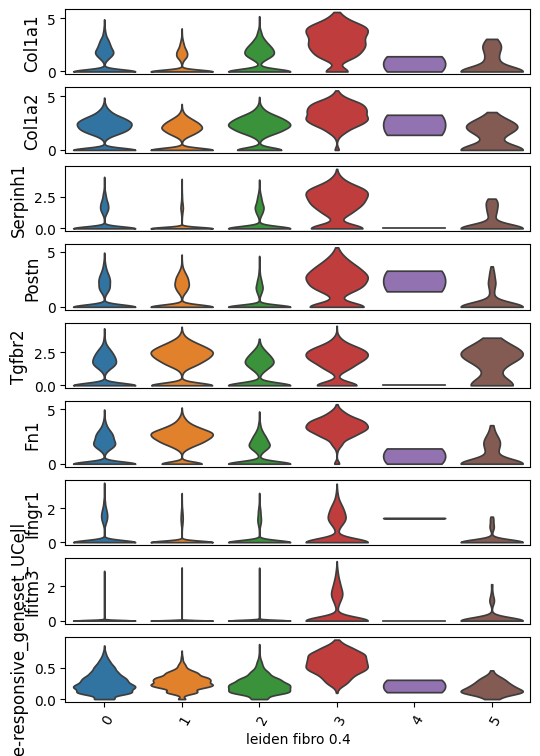

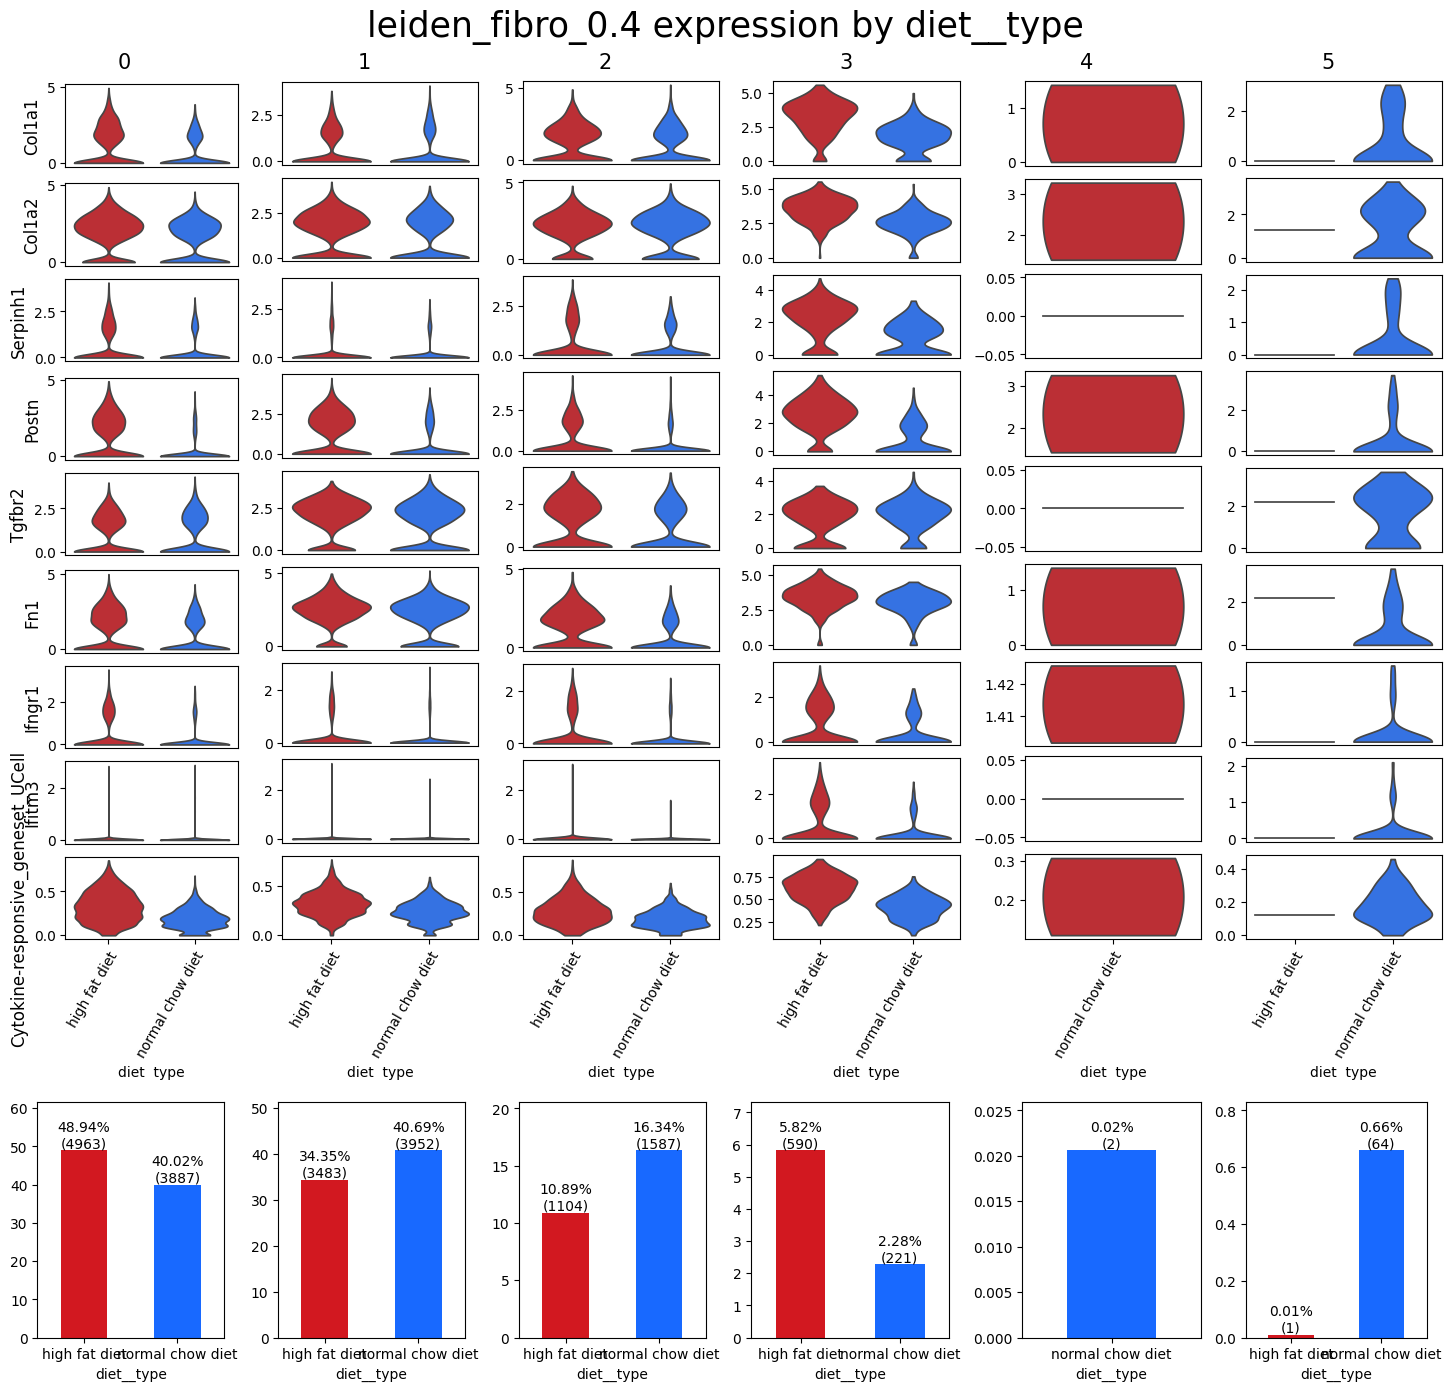

In [66]:
to_plot = custom_geneset["Cytokine-responsive_geneset"] + [
    "Cytokine-responsive_geneset_UCell"
]
plot_violinplot(ewat_fb_adata, res_key, to_plot, useStripPlot=False)
plot_cluster_violinplot(ewat_fb_adata, "diet__type", res_key, to_plot)

In [ ]:
for key in [col for col in adata.obs.columns if "leiden_fibro" in col]:
    plot_violinplot(fb_adata, key, cytokine_responses, useStripPlot=False)

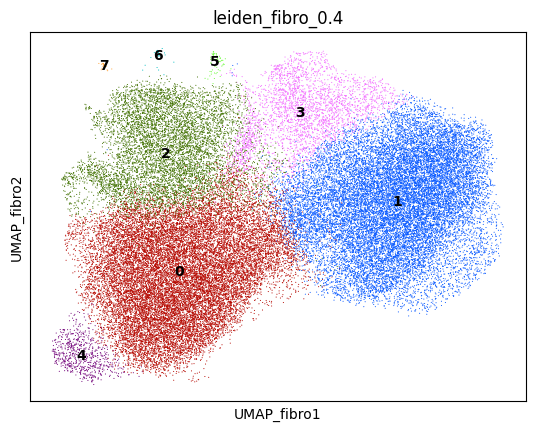

In [139]:
sc.pl.embedding(fb_adata, "UMAP_fibro", color="leiden_fibro_0.4", legend_loc="on data")

100%|██████████| 34/34 [00:02<00:00, 12.49it/s]


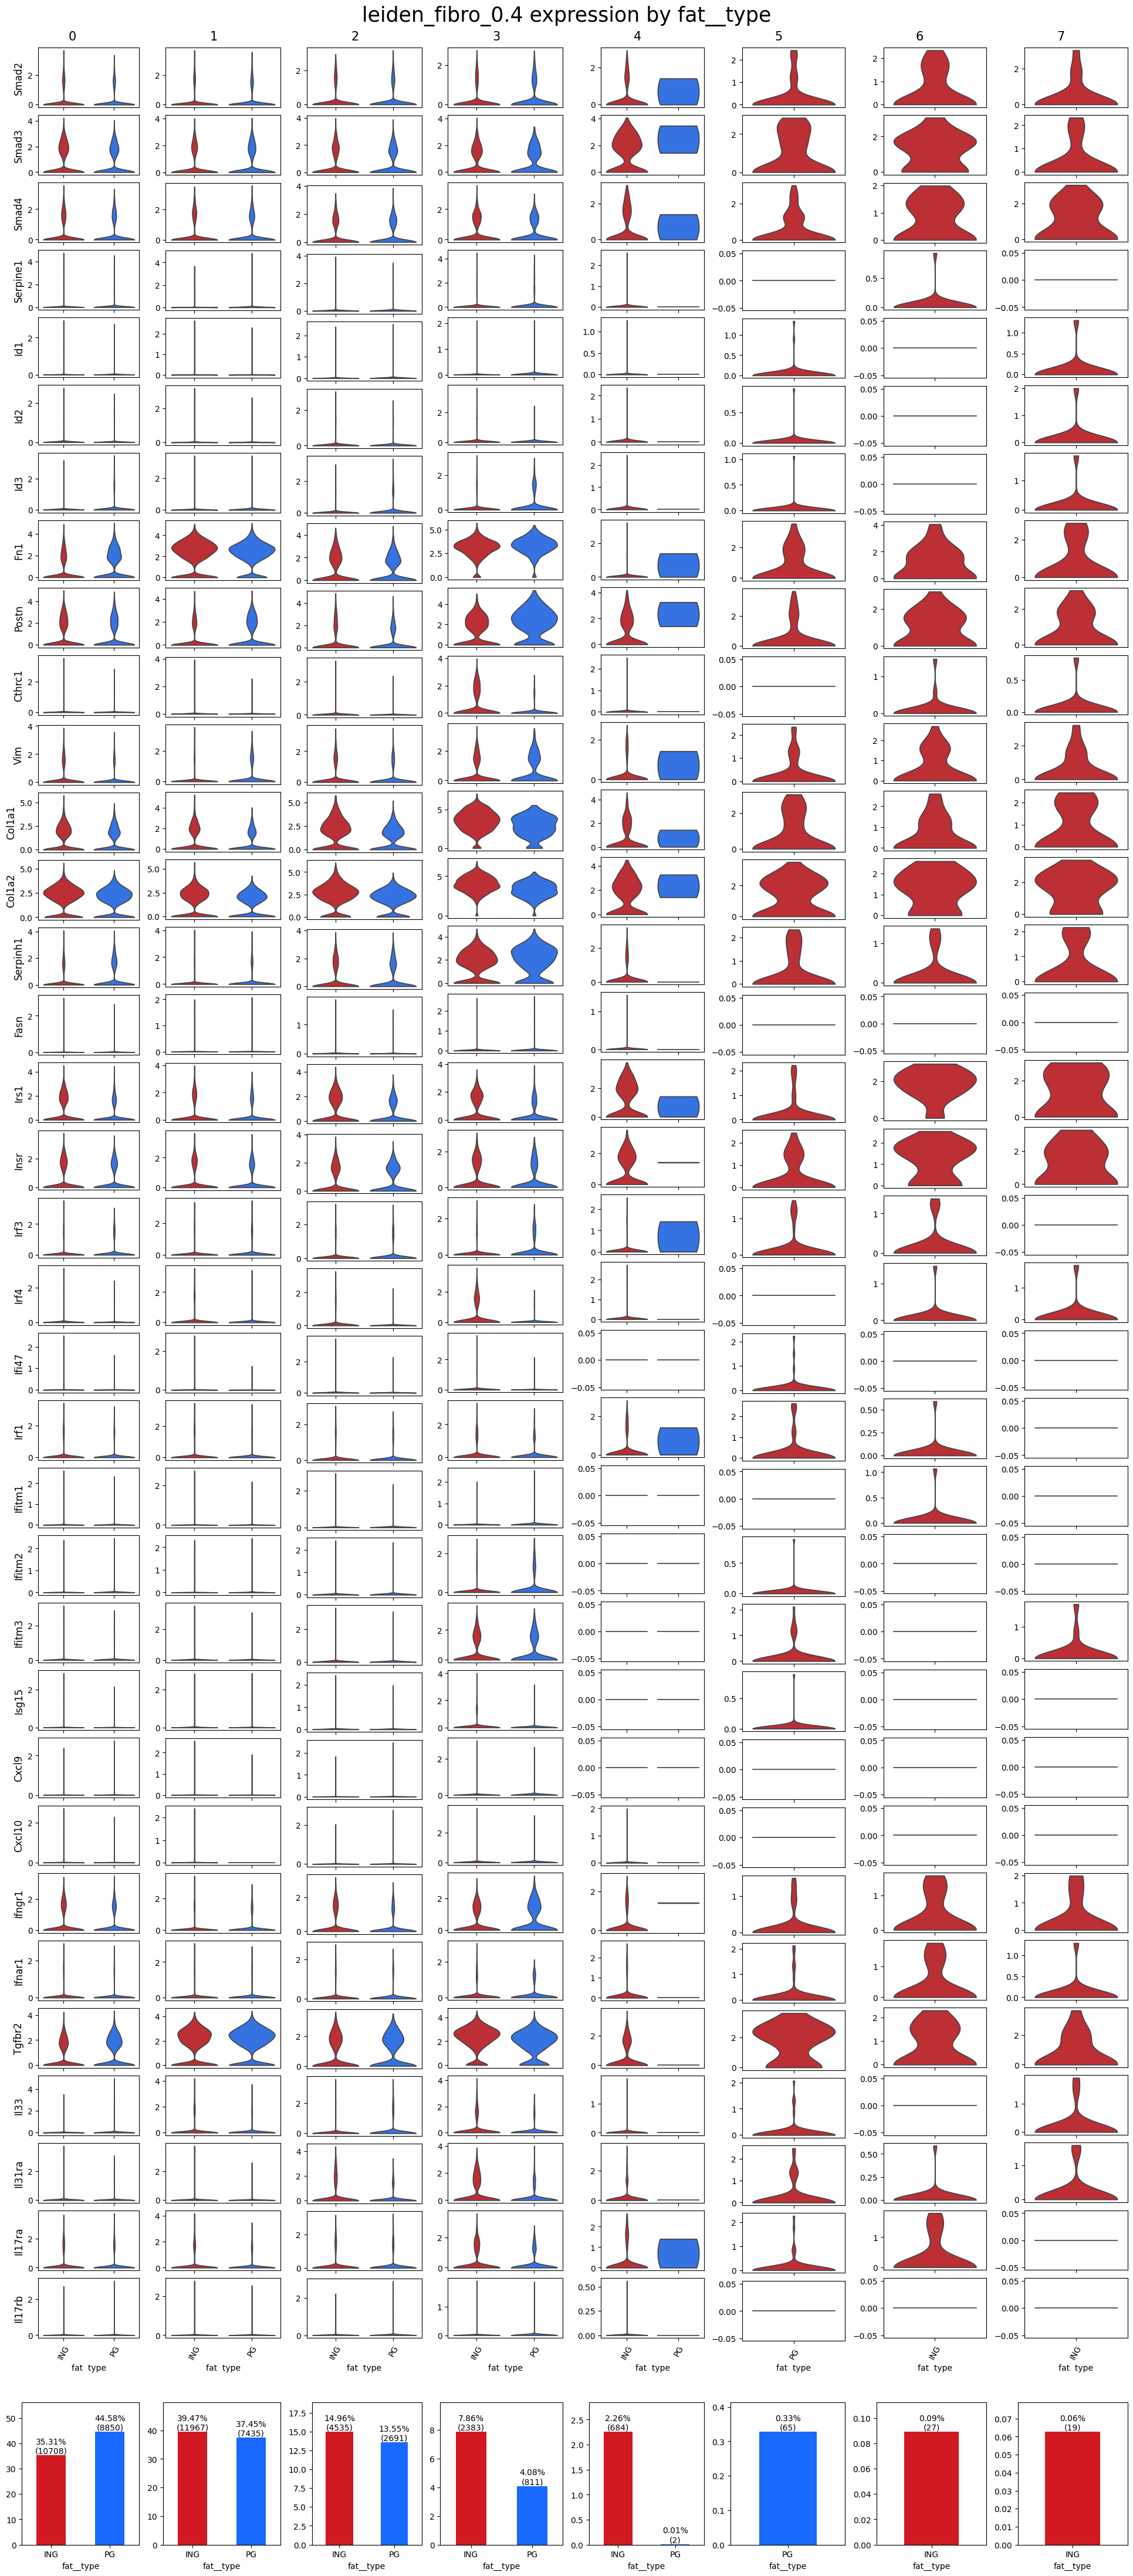

In [141]:
markers = [b for a in cytokine_responses for b in cytokine_responses[a]]
plot_cluster_violinplot(fb_adata, "fat__type", "leiden_fibro_0.4", markers)

deleted from `uns`:  leiden_fibro_0.4
deleted from `uns`:  leiden_fibro_0.4_colors


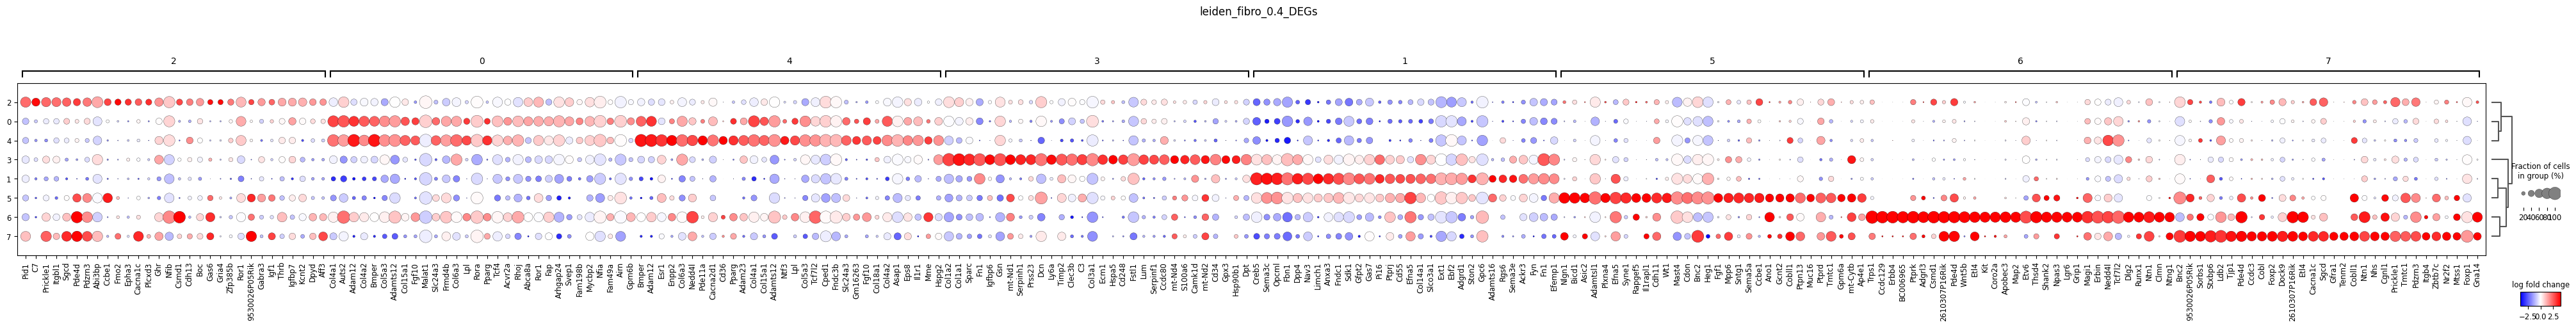

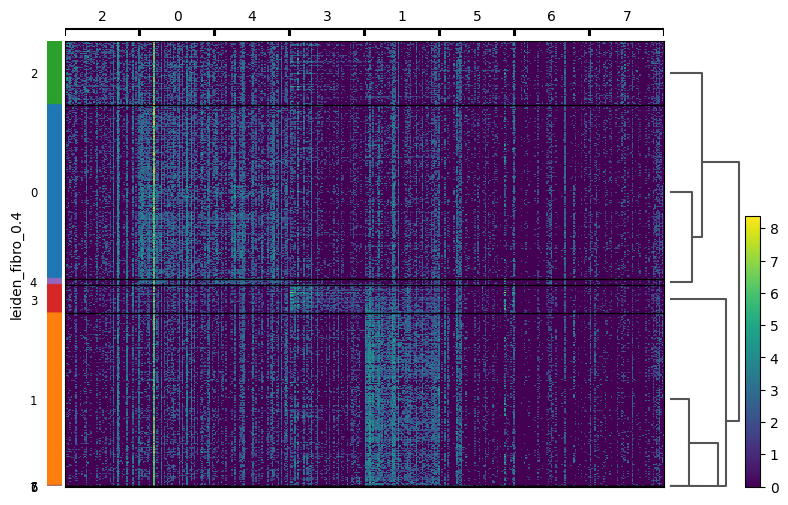

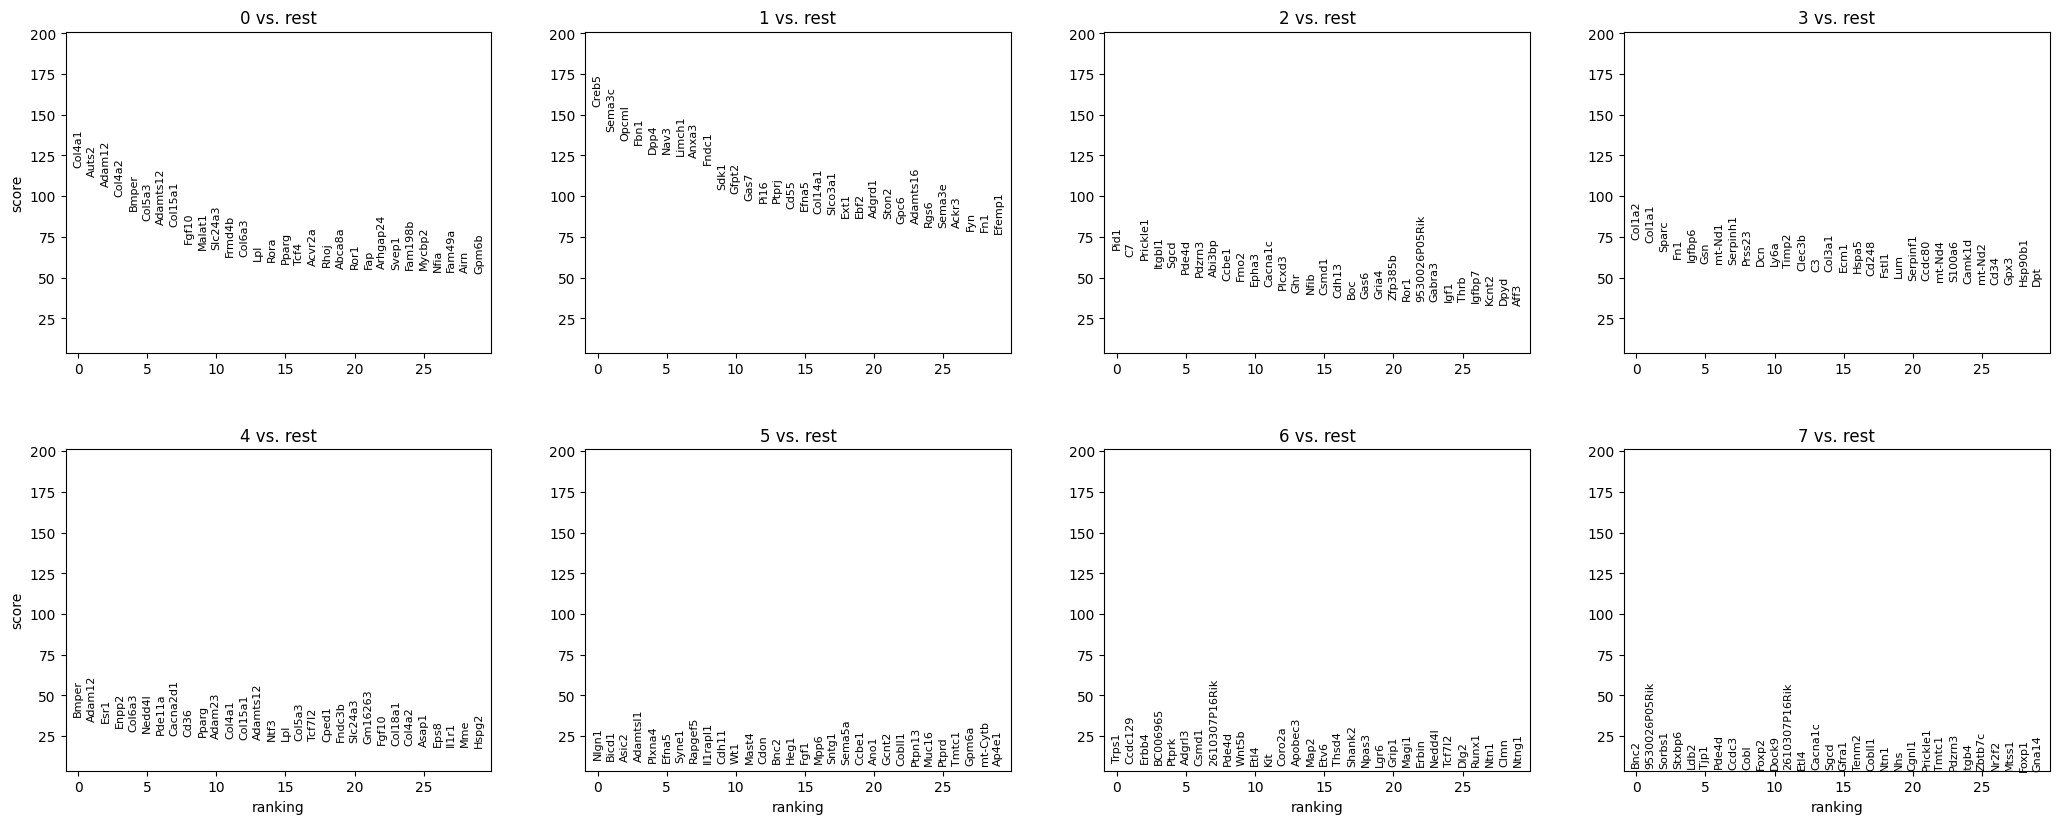

In [142]:
# original subclusters
RUN_DEG = True

# change to string for DEGs
for col in fb_adata.obs.columns:
    if CLUSTER_KEY in col:
        fb_adata.obs[col] = fb_adata.obs[col].astype(str).astype("category")

for res in SELECT_RES:
    res_key = f"{CLUSTER_KEY}_{res:.1f}"
    de_key = f"{DE_KEY}_{res:.1f}"
    n_clust = len(fb_adata.obs[res_key].unique())

    # calculate DEGs
    if RUN_DEG is True:
        clear_uns(fb_adata, res_key)
        sc.tl.rank_genes_groups(
            fb_adata,
            groupby=res_key,
            key_added=de_key,
            use_raw=False,
            layer="normalized",
            method="wilcoxon",
        )

    # plot DEGs
    top_genes = {}
    for group, df in sc.get.rank_genes_groups_df(
        fb_adata, group=None, key=de_key
    ).groupby("group"):
        top_genes[group] = df["names"][:30].tolist()
    f, ax = plt.subplots(1, 1, figsize=(n_clust * 5, 5), layout="constrained")
    sc.pl.rank_genes_groups_dotplot(
        fb_adata,
        groupby=res_key,
        key=de_key,
        # n_genes=20,
        var_names=top_genes,
        # standard_scale="var",
        values_to_plot="logfoldchanges",
        cmap="bwr",
        colorbar_title="log fold change",
        ax=ax,
        title=f"{res_key}_DEGs",
        vmin=-4,
        vmax=4,
    )

    sc.pl.rank_genes_groups_heatmap(
        fb_adata,
        key=de_key,
        groupby=res_key,
        layer="normalized",
        n_genes=50,
    )
    sc.pl.rank_genes_groups(fb_adata, key=de_key, n_genes=30, title=f"{res_key}_DEGs")

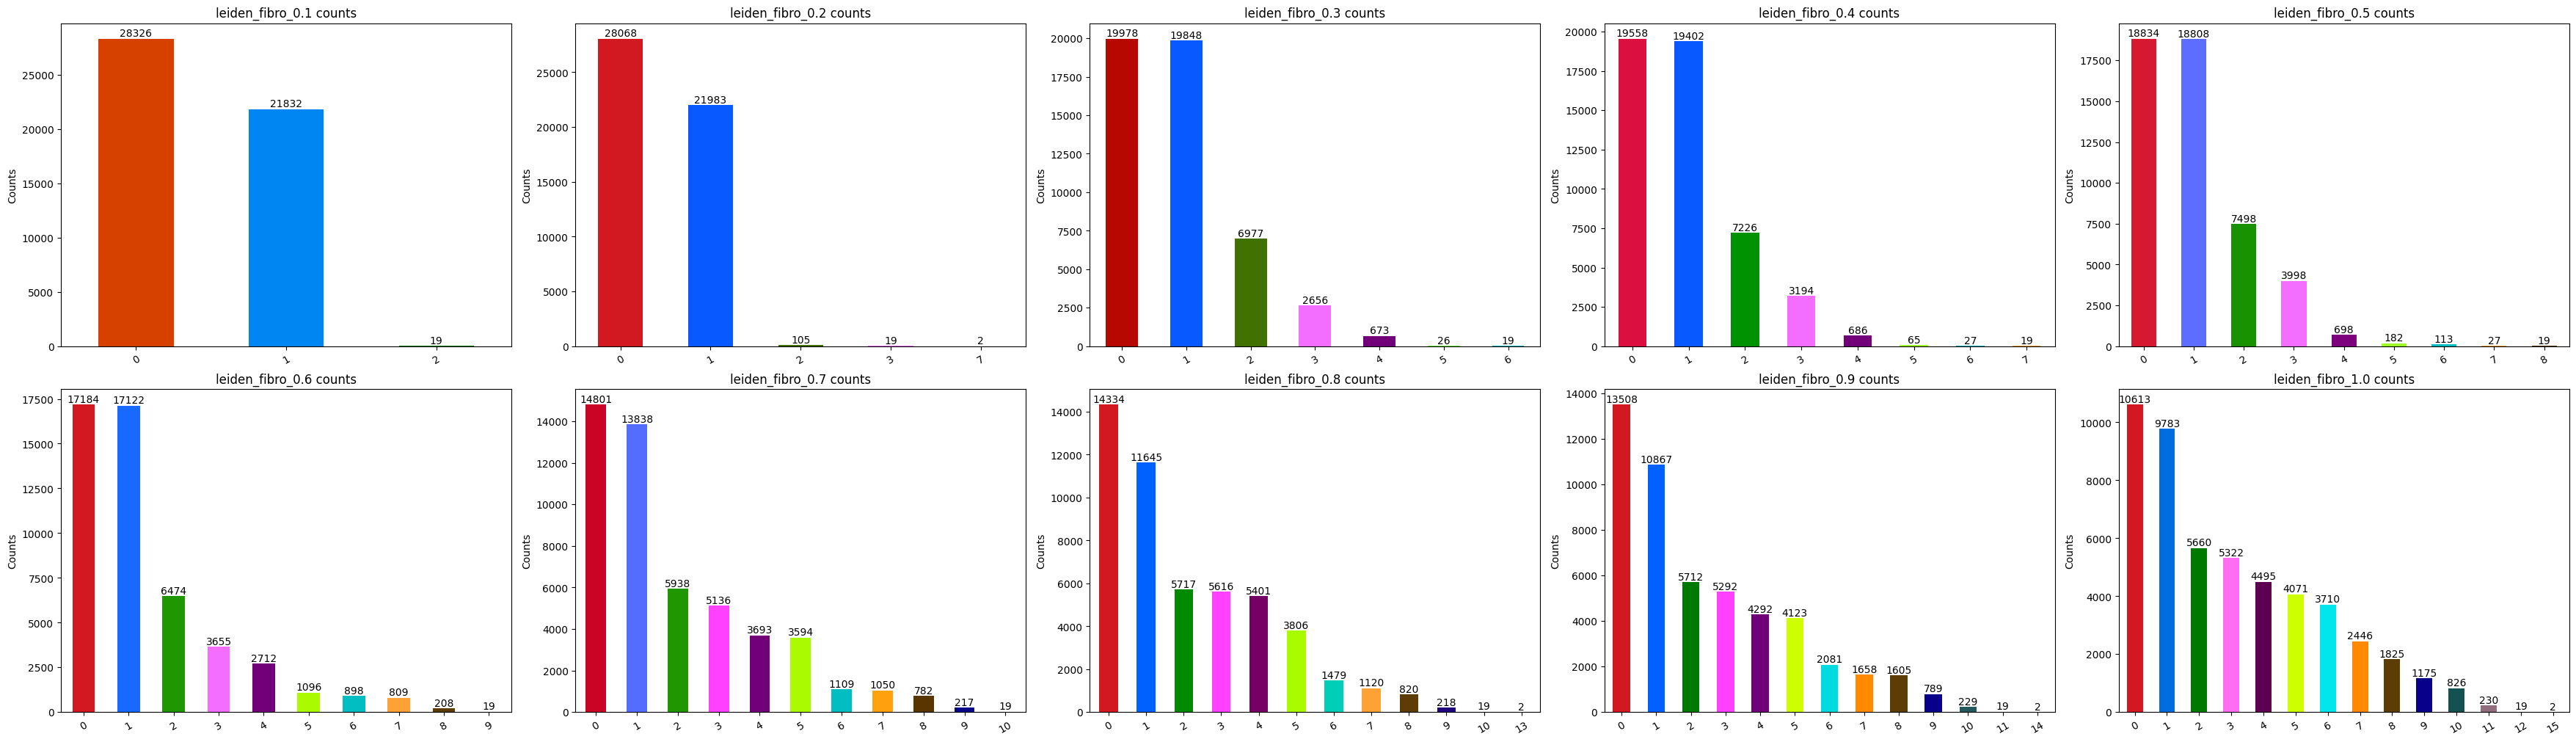

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

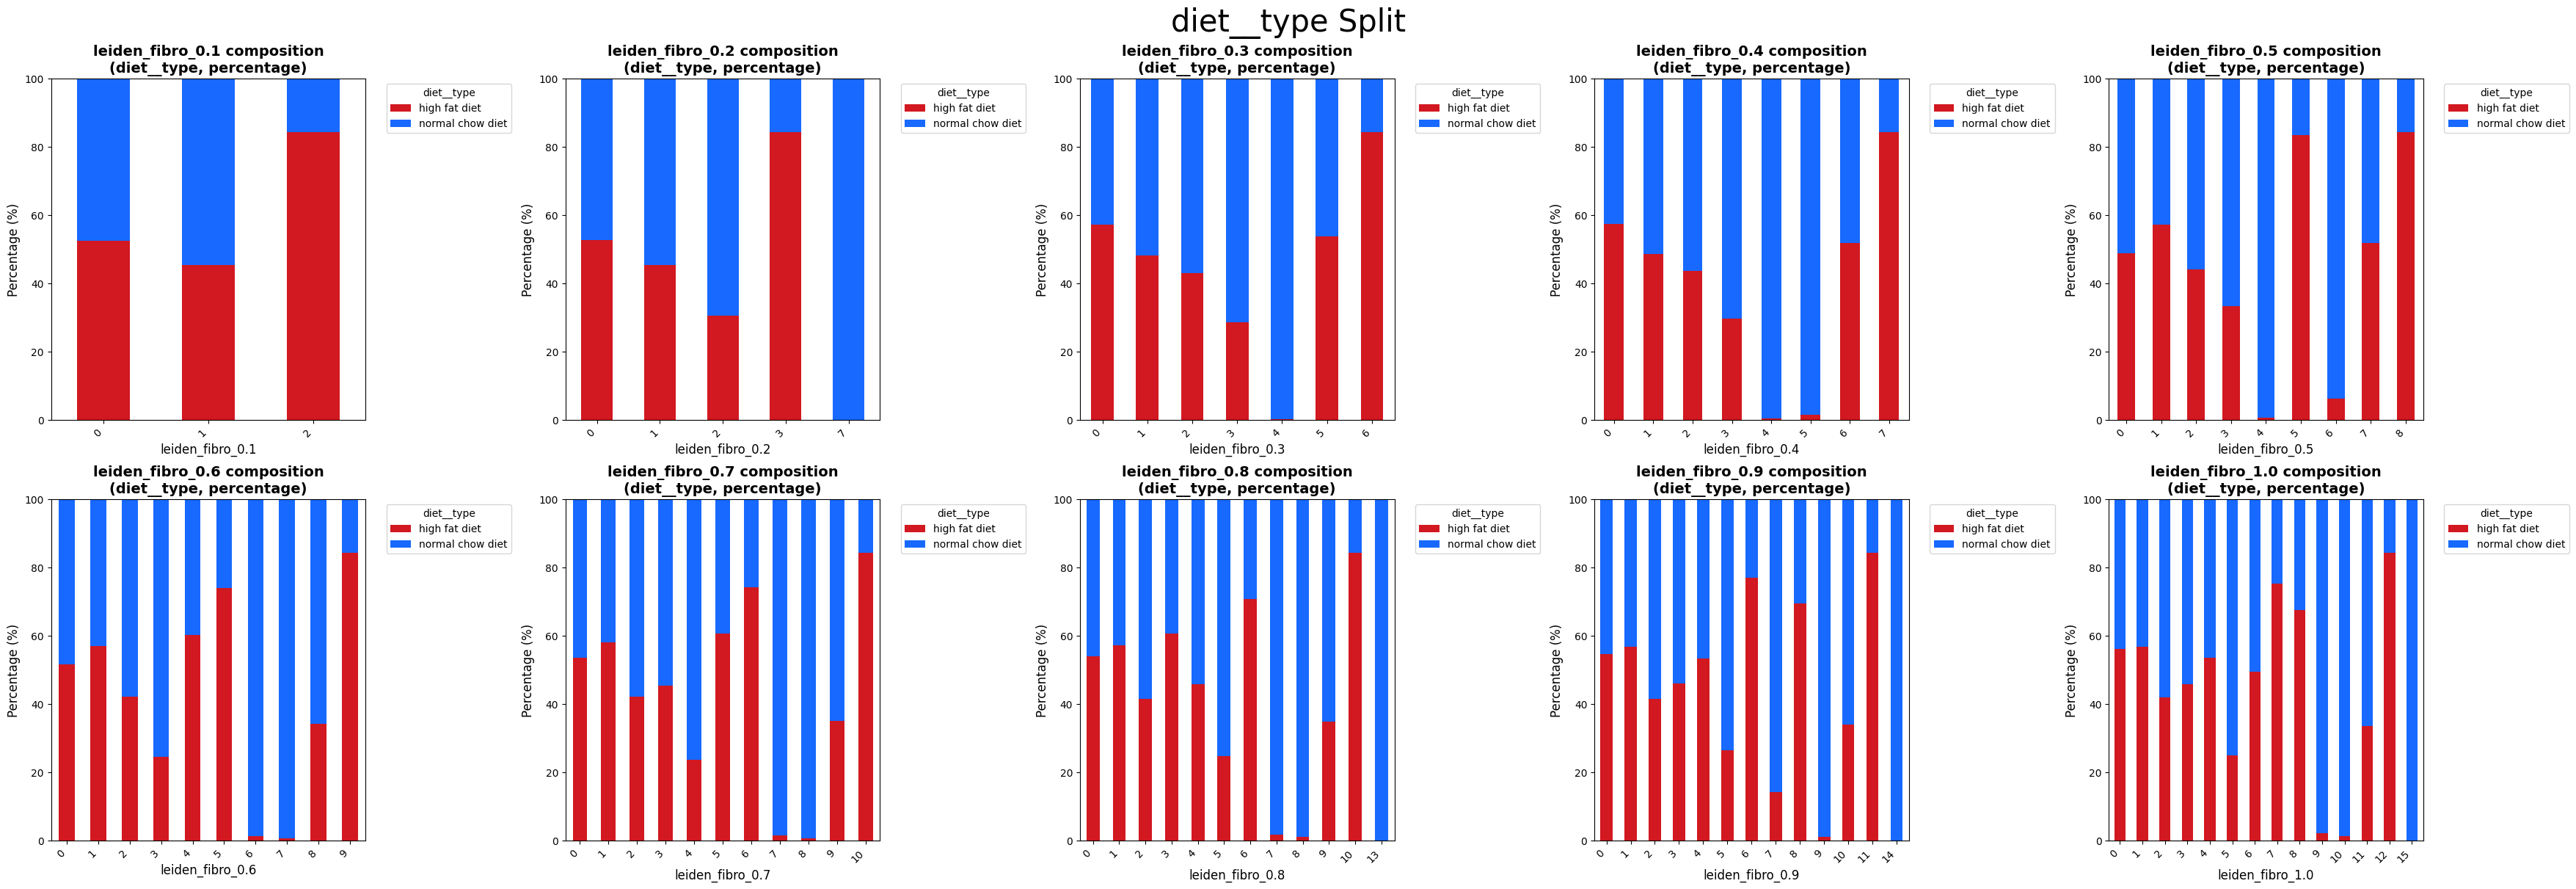

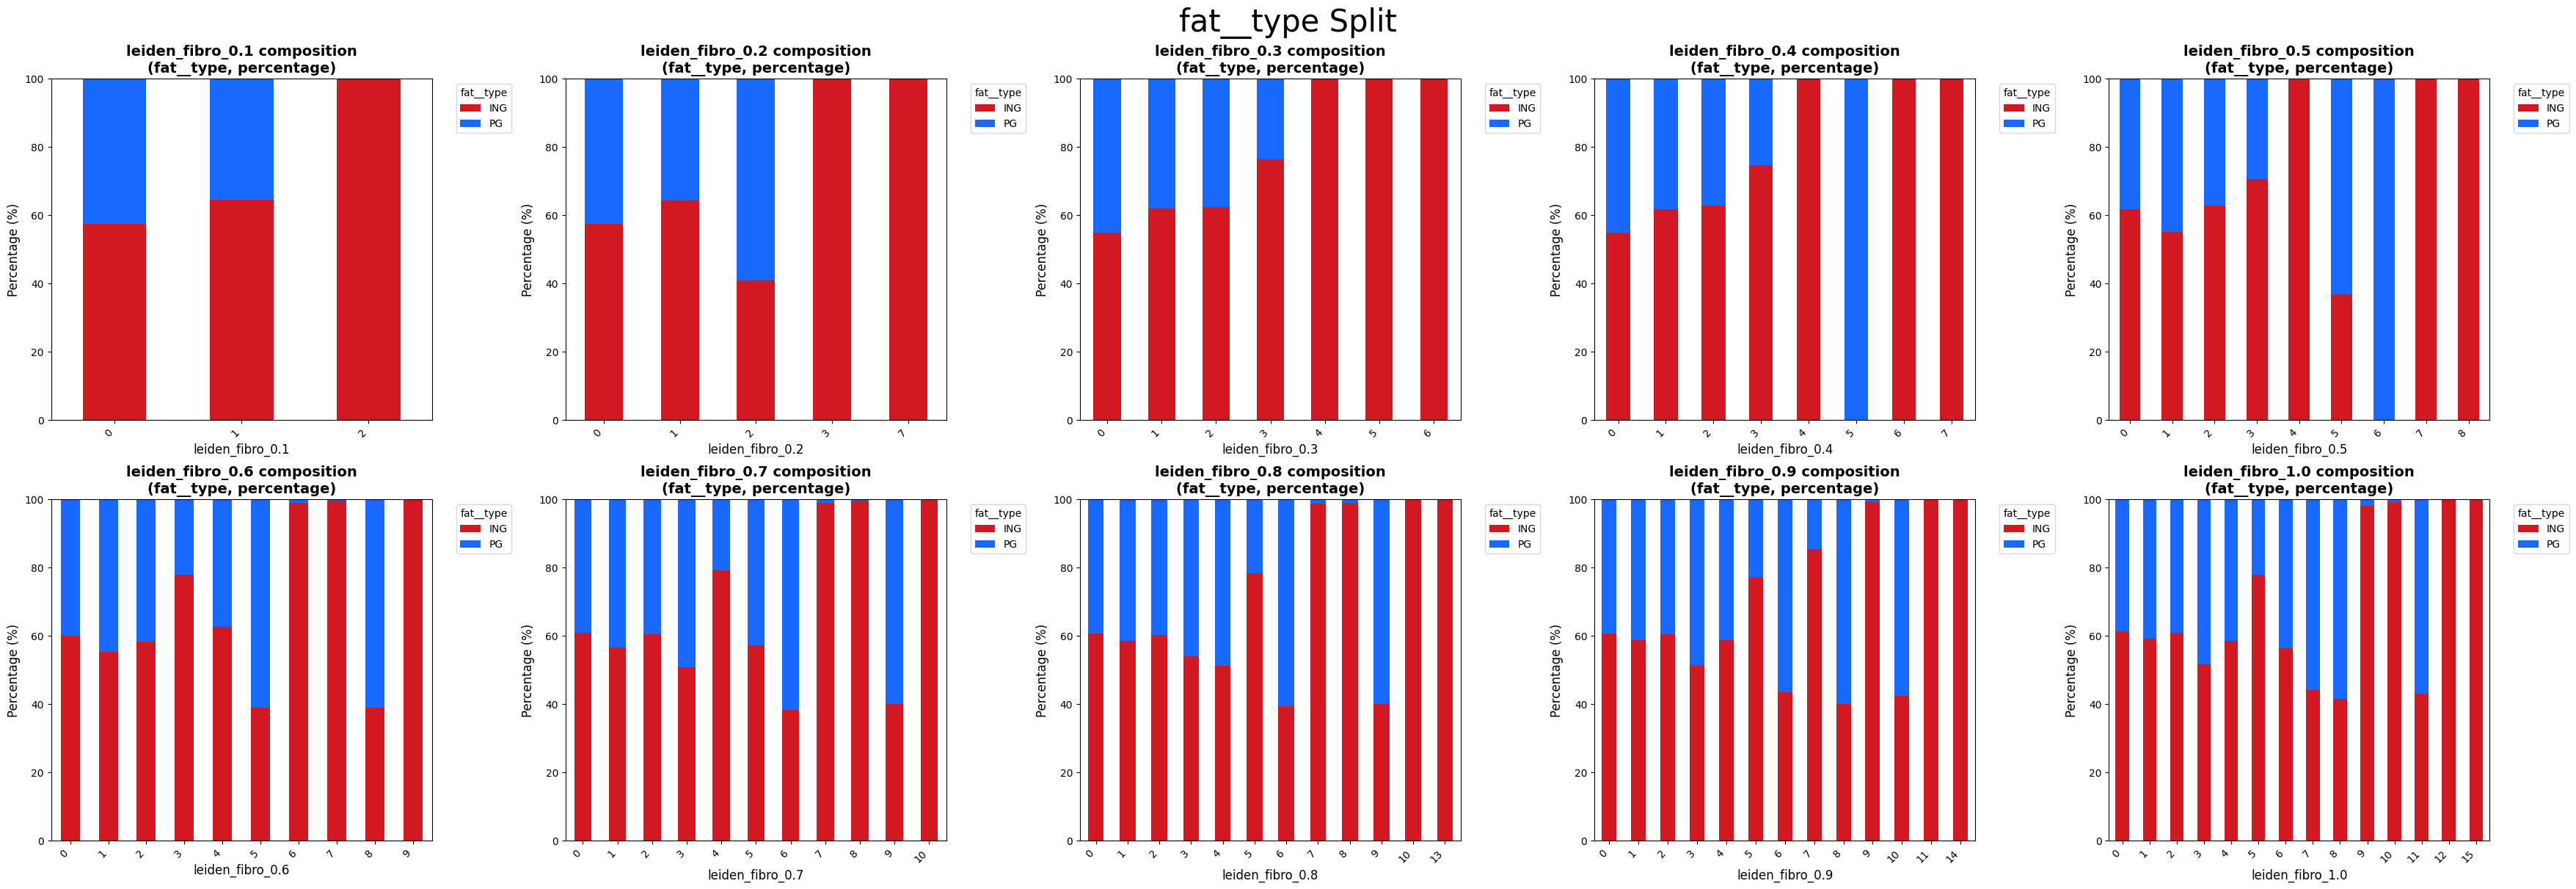

In [114]:
# barplot counts
for col in fb_adata.obs.columns:
    if "leiden_fibro" in col:
        fb_adata.obs[col] = fb_adata.obs[col].astype(int).astype("category")

# counts barplots
r, c = 2, 5
f, axs = plt.subplots(r, c, figsize=(7 * c, 5 * r), layout="constrained")
axs = axs.flatten()
for i, res in enumerate(resolutions):
    res_key = f"leiden_fibro_{res}"

    plt.figure()
    pd.Series(Counter(fb_adata.obs[res_key])).sort_index().plot(
        kind="bar", color=fb_adata.uns[f"{res_key}_colors"], rot=30, ax=axs[i]
    )
    axs[i].set_ylabel("Counts")
    axs[i].bar_label(axs[i].containers[0])
    axs[i].set_title(f"{res_key} counts")

# percentage barplots
for col in ["diet__type", "fat__type"]:
    r, c = 2, 5
    f, axs = plt.subplots(r, c, figsize=(7 * c, 6 * r), layout="constrained")
    axs = axs.flatten()
    for i, res in enumerate(resolutions):
        res_key = f"leiden_fibro_{res}"
        plot_cluster_stackedbarplot(fb_adata, res_key, col, pct=True, ax=axs[i])
    f.suptitle(col + " Split", size=30)

In [ ]:
fb_adata.write_zarr(DATADIR / study / "fibroblasts")
print(fb_adata)
gc.collect()

In [2]:
fb_adata = ad.read_zarr(DATADIR / study / "fibroblasts")
print(fb_adata)
gc.collect()

AnnData object with n_obs × n_vars = 50177 × 20499
    obs: 'Identifier', 'biosample_type', 'library_preparation_protocol__ontology_id', 'library_preparation_protocol__ontology_label', 'donor_id', 'species__ontology_id', 'species__ontology_label', 'organ__ontology_id', 'organ__ontology_label', 'tissue__ontology_id', 'tissue__ontology_label', 'tissue__type__ontology_id', 'tissue__type__ontology_label', 'depot__ontology_id', 'depot__ontology_label', 'fat__type', 'sex__ontology_id', 'sex__ontology_label', 'race__ontology_id', 'race__ontology_label', 'ethnicity__ontology_id', 'ethnicity__ontology_label', 'mouse_strain__ontology_id', 'mouse_strain__ontology_label', 'development_stage__ontology_id', 'development_stage__ontology_label', 'organism_age', 'organism_age__unit__ontology_id', 'organism_age__unit__ontology_label', 'organism_age__group', 'organism_weight', 'organism_weight__unit__ontology_id', 'organism_weight__unit__ontology_label', 'disease__ontology_id', 'disease__ontology_label',

2003